# Примеры визуализации результатов Covarion

Этот notebook показывает, как визуализировать результаты априорного
ковариационного анализа геодезических сетей.

В нём рассматриваются:

1. Ковариационная и корреляционная матрицы параметров сети
2. План сети, измерения и эллипсы погрешностей
3. Прямая угловая засечка
4. Обратная угловая засечка

Все визуализации строятся отдельным пакетом `covarion.visualization`.
Доменные классы сети и наблюдений не содержат зависимостей от Matplotlib
или Seaborn.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from covarion import (
    ControlPointObservation,
    GeodeticNetwork,
    GeodeticPoint,
    ObservationCovarianceMethod,
    SlopeDistanceObservation,
)
from covarion.visualization.covariance import (
    plot_correlation_matrix,
    plot_covariance_matrix,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

In [2]:
def make_point(
    name: str,
    easting: float,
    northing: float,
    height: float = 0.0,
) -> GeodeticPoint:
    return GeodeticPoint(
        name=name,
        coordinates=(easting, northing, height),
    )

## 1. Ковариационная и корреляционная матрицы

Сначала построим небольшую плановую сеть. Точки `A`, `B` и `C`
считаются исходными, а координаты точки `P` определяются по нескольким
наклонным расстояниям.

Для измерения расстояния Covarion использует модель точности:

$$
\sigma_D = a + b \cdot 10^{-6}D,
$$

где:

- $a$ — постоянная составляющая ошибки в метрах;
- $b$ — коэффициент, выраженный в ppm;
- $D$ — длина измеряемой линии.

После вычисления ковариации покажем:

- ковариационную матрицу в единицах параметров;
- корреляционную матрицу в интервале $[-1, 1]$.

In [3]:
covariance_network = GeodeticNetwork(
    name="Distance network for matrix visualization",
    points=(
        make_point("A", 0.0, 0.0),
        make_point("B", 120.0, 0.0),
        make_point("C", 20.0, 100.0),
        make_point("P", 55.0, 42.0),
    ),
)

In [4]:
matrix_method = ObservationCovarianceMethod(
    observations=(
        ControlPointObservation.fixed(
            name="A_fixed",
            point_name="A",
            axes=("X", "Y", "H"),
            coordinates=(0.0, 0.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="B_fixed",
            point_name="B",
            axes=("X", "Y", "H"),
            coordinates=(120.0, 0.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="C_fixed",
            point_name="C",
            axes=("X", "Y", "H"),
            coordinates=(20.0, 100.0, 0.0),
        ),
        SlopeDistanceObservation(
            name="A_to_P",
            from_point="A",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
        SlopeDistanceObservation(
            name="B_to_P",
            from_point="B",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
        SlopeDistanceObservation(
            name="C_to_P",
            from_point="C",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
    ),
)

Для получения полной трёхмерной ковариационной матрицы высота точки
`P` должна быть определена. Наклонные расстояния содержат вертикальную
составляющую только при ненулевых разностях высот; в данном плоском
примере все высоты равны нулю.

Поэтому добавим жёсткое условие на $H_P$, чтобы выделить анализ
планового блока $E_P, N_P$.

In [5]:
matrix_method = ObservationCovarianceMethod(
    observations=(
        ControlPointObservation.fixed(
            name="A_fixed",
            point_name="A",
            axes=("X", "Y", "H"),
            coordinates=(0.0, 0.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="B_fixed",
            point_name="B",
            axes=("X", "Y", "H"),
            coordinates=(120.0, 0.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="C_fixed",
            point_name="C",
            axes=("X", "Y", "H"),
            coordinates=(20.0, 100.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="P_height_fixed",
            point_name="P",
            axes=("H",),
            coordinates=(0.0,),
        ),
        SlopeDistanceObservation(
            name="A_to_P",
            from_point="A",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
        SlopeDistanceObservation(
            name="B_to_P",
            from_point="B",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
        SlopeDistanceObservation(
            name="C_to_P",
            from_point="C",
            to_point="P",
            constant_error=0.002,
            ppm_error=2.0,
        ),
    ),
)

In [6]:
matrix_covariance = covariance_network.compute_covariance(
    matrix_method,
)

matrix_covariance

NetworkCovariance(matrix=array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.22362874e-38,  8.89954461e-23,  0.00000000e+00,
         1.10094289e-22, -3.53211273e-22,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         4.02438112e-38,  1.12567998e-22,  0.00000000e+00,
         0.00000000e+00,  7.91591397e-23,  0.00000000e+00],
       [ 0.00000000e+00,  0

In [7]:
parameter_labels = list(
    matrix_covariance.standard_deviations.keys()
)

print("СКП параметров:")

for parameter_name, standard_deviation in (
    matrix_covariance.standard_deviations.items()
):
    print(
        f"{parameter_name:>6}: "
        f"{standard_deviation:.6e}"
    )

СКП параметров:
   A_X: 0.000000e+00
   A_Y: 0.000000e+00
   A_H: 0.000000e+00
   B_X: 0.000000e+00
   B_Y: 0.000000e+00
   B_H: 0.000000e+00
   C_X: -0.000000e+00
   C_Y: 0.000000e+00
   C_H: 0.000000e+00
   P_X: 1.648119e-03
   P_Y: 1.766405e-03
   P_H: 0.000000e+00


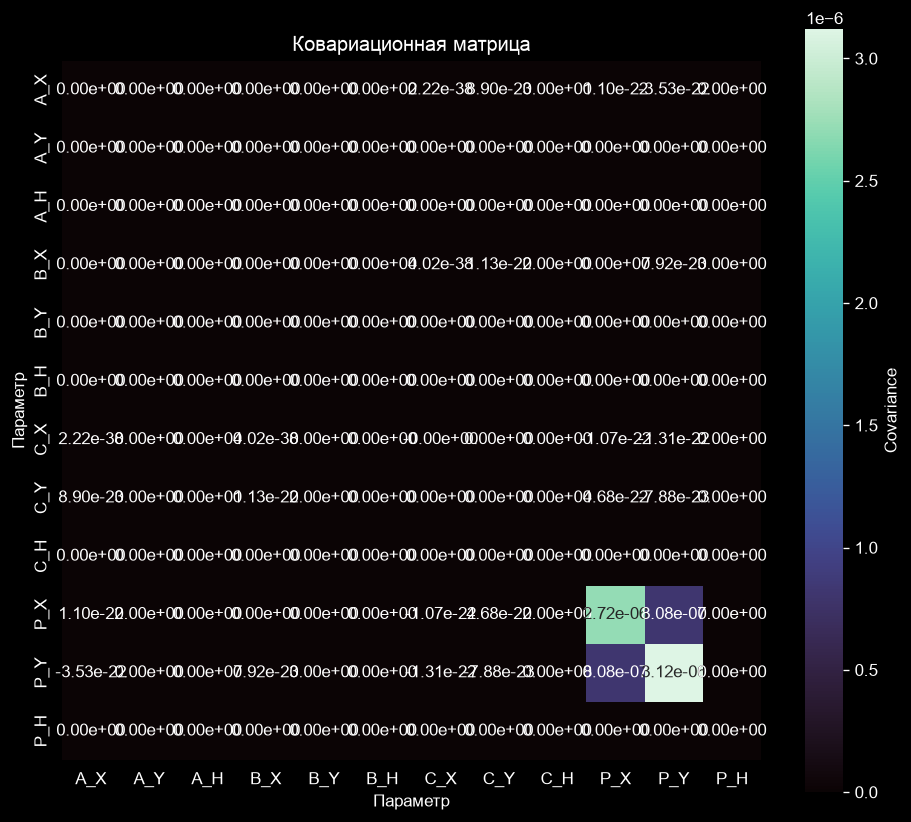

In [8]:
figure, axes = plot_covariance_matrix(
    matrix_covariance.matrix,
    parameter_labels,
    annotate=True,
)

figure.tight_layout()
plt.show()

Диагональ ковариационной матрицы содержит дисперсии параметров:

$$
\sigma_{x_i}^2 = C_{ii}.
$$

Внедиагональные элементы содержат ковариации. Их наличие означает,
что ошибки параметров статистически связаны: изменение одной
координаты при уравнивании компенсируется изменением другой.

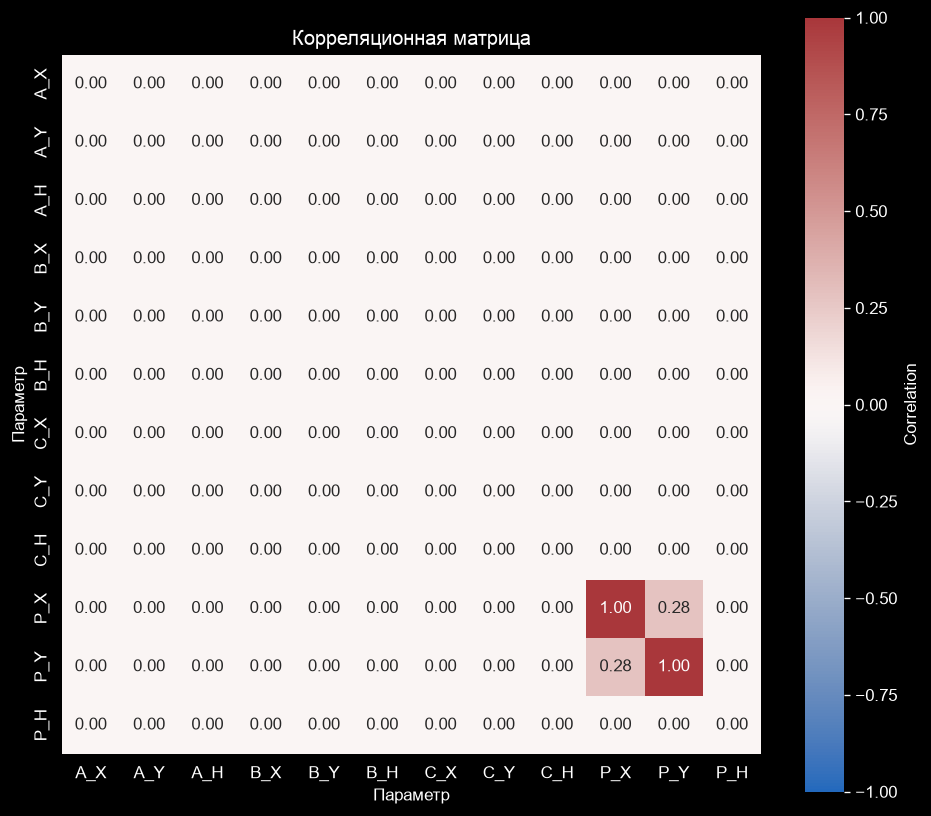

In [9]:
figure, axes = plot_correlation_matrix(
    matrix_covariance.matrix,
    parameter_labels,
    annotate=True,
)

figure.tight_layout()
plt.show()

Корреляционная матрица нормирует ковариации:

$$
\rho_{ij} =
\frac{C_{ij}}
{\sigma_{x_i}\sigma_{x_j}}.
$$

Её элементы лежат в диапазоне:

$$
-1 \leq \rho_{ij} \leq 1.
$$

Положительная корреляция означает согласованное изменение параметров,
отрицательная — компенсирующее. Сильные по модулю корреляции часто
указывают на слабую геометрию сети либо недостаток независимых
наблюдений.

---

## 2. План сети, измерения и эллипсы погрешностей

Теперь отобразим геометрию сети в плане:

- пункты `A`, `B`, `C` и `P`;
- жёсткие опорные условия;
- линии наклонных расстояний;
- 95%-эллипсы погрешностей.

Реальные размеры эллипсов обычно существенно меньше размеров сети.
Поэтому параметр `display_scale` используется только для увеличения
отображения на плане и не влияет на рассчитанную ковариационную матрицу.

In [10]:
from covarion.visualization.context import NetworkPlotContext
from covarion.visualization.layers.error_ellipses import (
    ErrorEllipseLayer,
)
from covarion.visualization.layers.observations import (
    ObservationLayer,
)
from covarion.visualization.layers.points import PointLayer
from covarion.visualization.network import NetworkPlot
from covarion.visualization.renderers import (
    default_observation_renderers,
)

In [11]:
matrix_plot_context = NetworkPlotContext(
    network=covariance_network,
    covariance=matrix_covariance,
    observations=matrix_method.observations,
)

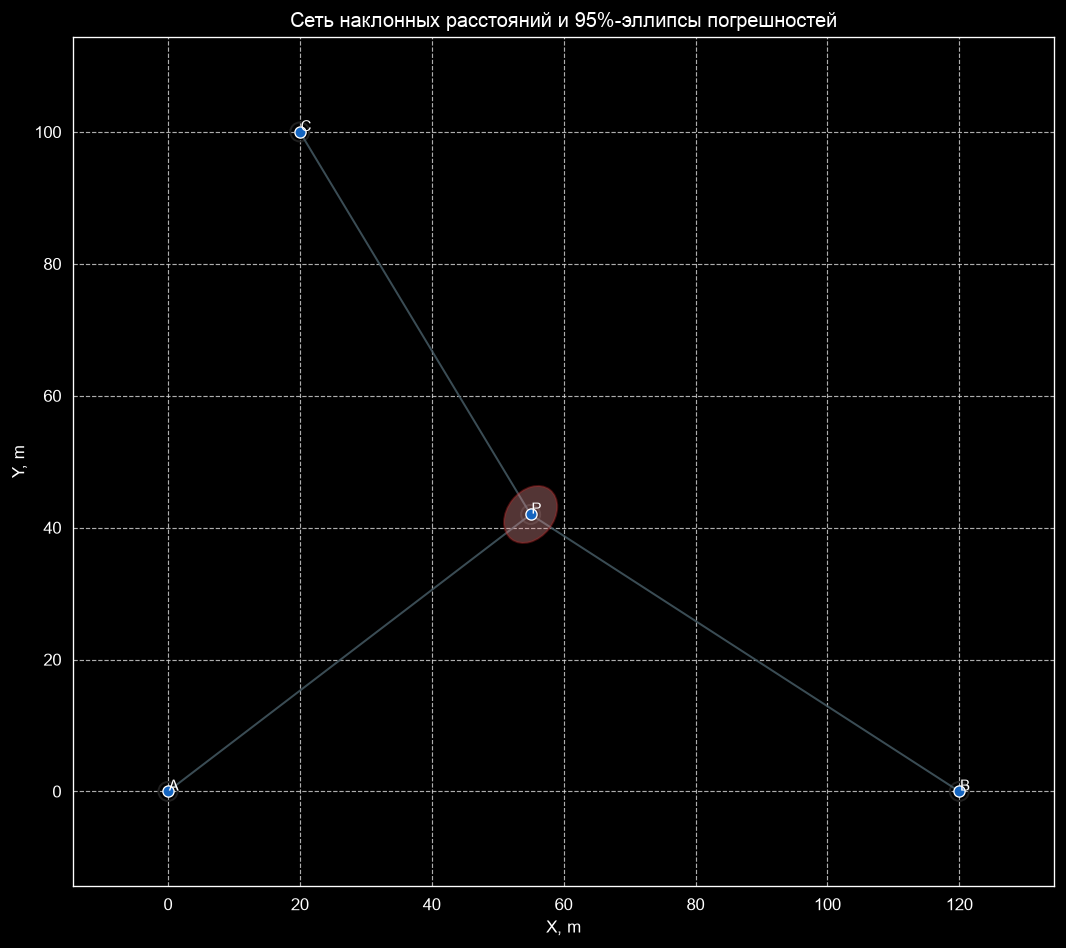

In [12]:
network_plot = NetworkPlot(
    title="Сеть наклонных расстояний и 95%-эллипсы погрешностей",
    margin_fraction=0.12,
    equal_aspect=True,
    show_grid=True,
)

network_plot.extend_layers(
    (
        ObservationLayer(
            renderers=default_observation_renderers(),
            report_unsupported=True,
        ),
        ErrorEllipseLayer(
            confidence_level=0.95,
            display_scale=1_000.0,
        ),
        PointLayer(
            show_labels=True,
        ),
    )
)

figure, axes = network_plot.draw(
    matrix_plot_context,
    figsize=(10.0, 8.0),
)

axes.set_xlabel("X, m")
axes.set_ylabel("Y, m")

figure.tight_layout()
plt.show()

In [13]:
p_covariance = matrix_covariance.diagonal_block("P")

sigma_x = np.sqrt(p_covariance[0, 0])
sigma_y = np.sqrt(p_covariance[1, 1])

correlation_xy = (
    p_covariance[0, 1]
    / (sigma_x * sigma_y)
)

print("Плановый ковариационный блок точки P:")
print(p_covariance[:2, :2])

print()
print(f"σ_X(P): {sigma_x:.6e} m")
print(f"σ_Y(P): {sigma_y:.6e} m")
print(f"ρ_XY(P): {correlation_xy:.6f}")
print("Доверительный уровень эллипса: 95 %")
print("Визуальный масштаб эллипсов: 1:1000")

Плановый ковариационный блок точки P:
[[2.71629490e-06 8.08400021e-07]
 [8.08400021e-07 3.12018507e-06]]

σ_X(P): 1.648119e-03 m
σ_Y(P): 1.766405e-03 m
ρ_XY(P): 0.277682
Доверительный уровень эллипса: 95 %
Визуальный масштаб эллипсов: 1:1000


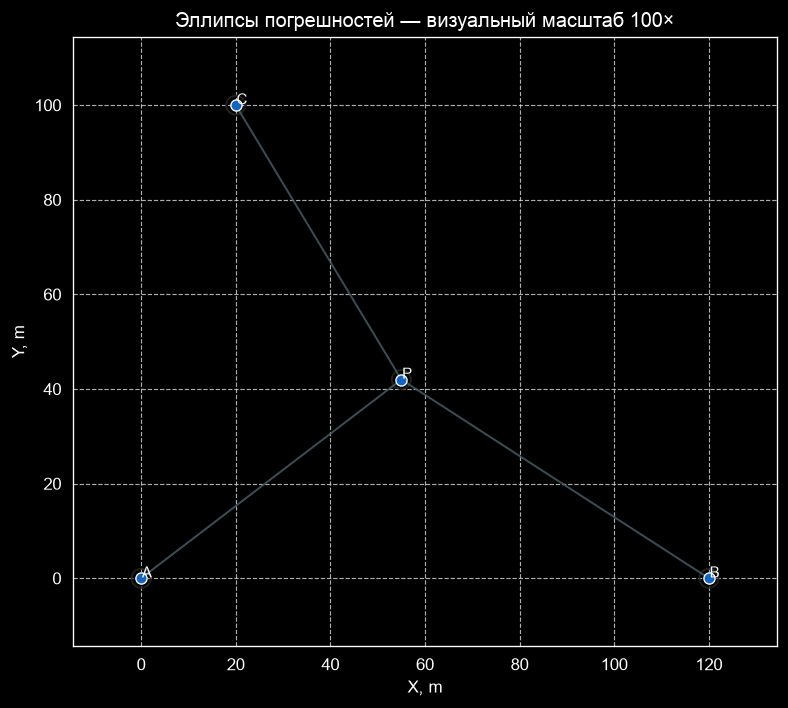

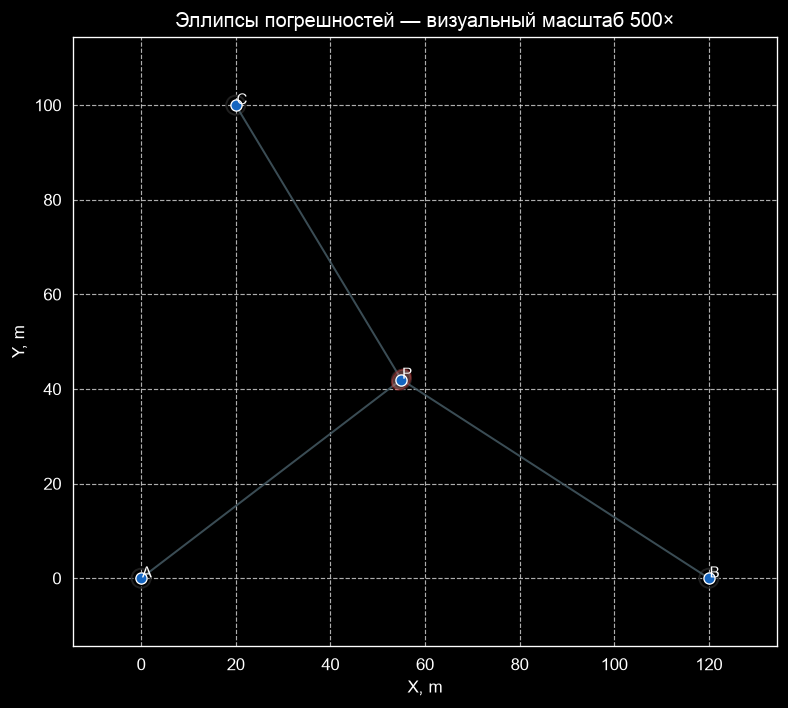

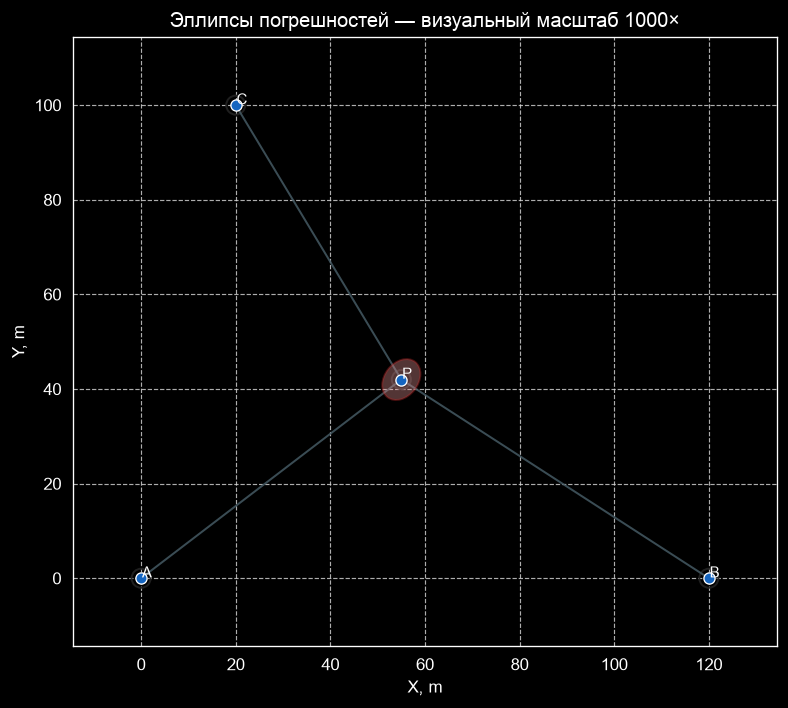

In [14]:
ellipse_scales = (
    100.0,
    500.0,
    1_000.0,
)

figures = []

for display_scale in ellipse_scales:
    comparison_plot = NetworkPlot(
        title=(
            "Эллипсы погрешностей "
            f"— визуальный масштаб {display_scale:.0f}×"
        ),
        margin_fraction=0.12,
        equal_aspect=True,
        show_grid=True,
    )

    comparison_plot.extend_layers(
        (
            ObservationLayer(
                renderers=default_observation_renderers(),
            ),
            ErrorEllipseLayer(
                confidence_level=0.95,
                display_scale=display_scale,
            ),
            PointLayer(
                show_labels=True,
            ),
        )
    )

    figure, axes = comparison_plot.draw(
        matrix_plot_context,
        figsize=(8.0, 6.0),
    )

    axes.set_xlabel("X, m")
    axes.set_ylabel("Y, m")

    figure.tight_layout()
    figures.append(figure)

plt.show()

### Интерпретация

Эллипс погрешностей строится из планового ковариационного блока:

$$
\mathbf{C}_{XY} =
\begin{bmatrix}
\sigma_X^2 & \sigma_{XY} \\
\sigma_{XY} & \sigma_Y^2
\end{bmatrix}.
$$

Главные направления и размеры эллипса определяются собственными
значениями и собственными векторами этой матрицы.

- Большая полуось указывает направление наибольшей неопределённости.
- Малая полуось указывает лучше определяемое направление.
- Поворот эллипса показывает корреляцию ошибок координат.
- Чем меньше эллипс, тем выше точность положения точки.

В этой сети точка `P` определяется расстояниями до трёх закреплённых
пунктов. Разнонаправленные линии `A–P`, `B–P` и `C–P` улучшают геометрию
и уменьшают неопределённость положения `P`.

---

## 3. Висячий теодолитный ход из пяти станций

Рассмотрим висячий теодолитный ход, исходящий из закреплённого пункта
`A` и проходящий через пять определяемых станций:

$$
A \rightarrow T_1 \rightarrow T_2 \rightarrow T_3 \rightarrow T_4
\rightarrow T_5.
$$

Пункт `A` является исходным. На каждой станции измеряются:

- расстояние до следующей станции;
- горизонтальные направления на заднюю и переднюю точки.

Горизонтальные направления внутри каждого `TotalStationSetup` приводятся
к разностям направлений. Это исключает общий ноль лимба станции, но
оставляет информацию об угле между задним и передним направлением.

Ход является висячим: он не замыкается на второй исходный пункт.
Поэтому неопределённость координат накапливается к конечной точке
`T5`.

In [15]:
from covarion import (
    TotalStationSetup,
    TotalStationSight,
    AzimuthObservation,
)

In [16]:
def arcseconds_to_radians(
    arcseconds: float,
) -> float:
    return np.deg2rad(arcseconds / 3600.0)

In [17]:
traverse_network = GeodeticNetwork(
    name="Five-station hanging theodolite traverse",
    points=(
        make_point("A", 0.0, 0.0, 0.0),

        make_point("T1", 55.0, 10.0, 0.0),
        make_point("T2", 105.0, 45.0, 0.0),
        make_point("T3", 150.0, 25.0, 0.0),
        make_point("T4", 205.0, 65.0, 0.0),
        make_point("T5", 260.0, 50.0, 0.0),
    ),
)

In [18]:
direction_sigma = arcseconds_to_radians(2.0)

t1_setup = TotalStationSetup(
    name="T1_setup",
    station="T1",
    reference_target="A",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="A",
            horizontal_standard_deviation=direction_sigma,
        ),
        TotalStationSight(
            target="T2",
            horizontal_standard_deviation=direction_sigma,
        ),
    ),
)

t2_setup = TotalStationSetup(
    name="T2_setup",
    station="T2",
    reference_target="T1",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T1",
            horizontal_standard_deviation=direction_sigma,
        ),
        TotalStationSight(
            target="T3",
            horizontal_standard_deviation=direction_sigma,
        ),
    ),
)

t3_setup = TotalStationSetup(
    name="T3_setup",
    station="T3",
    reference_target="T2",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T2",
            horizontal_standard_deviation=direction_sigma,
        ),
        TotalStationSight(
            target="T4",
            horizontal_standard_deviation=direction_sigma,
        ),
    ),
)

t4_setup = TotalStationSetup(
    name="T4_setup",
    station="T4",
    reference_target="T3",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T3",
            horizontal_standard_deviation=direction_sigma,
        ),
        TotalStationSight(
            target="T5",
            horizontal_standard_deviation=direction_sigma,
        ),
    ),
)

In [19]:
traverse_distances = (
    SlopeDistanceObservation(
        name="A_to_T1",
        from_point="A",
        to_point="T1",
        constant_error=0.002,
        ppm_error=2.0,
    ),
    SlopeDistanceObservation(
        name="T1_to_T2",
        from_point="T1",
        to_point="T2",
        constant_error=0.002,
        ppm_error=2.0,
    ),
    SlopeDistanceObservation(
        name="T2_to_T3",
        from_point="T2",
        to_point="T3",
        constant_error=0.002,
        ppm_error=2.0,
    ),
    SlopeDistanceObservation(
        name="T3_to_T4",
        from_point="T3",
        to_point="T4",
        constant_error=0.002,
        ppm_error=2.0,
    ),
    SlopeDistanceObservation(
        name="T4_to_T5",
        from_point="T4",
        to_point="T5",
        constant_error=0.002,
        ppm_error=2.0,
    ),
)

In [20]:
initial_azimuth = AzimuthObservation(
    name="A_to_T1_azimuth",
    from_point="A",
    to_point="T1",
    standard_deviation=arcseconds_to_radians(2.0),
    east_axis="X",
    north_axis="Y",
)

In [21]:
traverse_height_constraints = tuple(
    ControlPointObservation.fixed(
        name=f"{point_name}_height_fixed",
        point_name=point_name,
        axes=("H",),
        coordinates=(0.0,),
    )
    for point_name in ("T1", "T2", "T3", "T4", "T5")
)

traverse_method = ObservationCovarianceMethod(
    observations=(
        ControlPointObservation.fixed(
            name="A_fixed",
            point_name="A",
            axes=("X", "Y", "H"),
            coordinates=(0.0, 0.0, 0.0),
        ),
        *traverse_height_constraints,
        initial_azimuth,
        *traverse_distances,
        t1_setup,
        t2_setup,
        t3_setup,
        t4_setup,
    ),
)

In [22]:
traverse_covariance = traverse_network.compute_covariance(
    traverse_method,
)

traverse_covariance

NetworkCovariance(matrix=array([[ 2.33870027e-23,  4.18669536e-23,  0.00000000e+00,
         2.96943580e-21, -2.14224716e-22,  0.00000000e+00,
         2.20080228e-21,  1.60426833e-21,  0.00000000e+00,
         2.00897779e-21, -2.29007406e-21,  0.00000000e+00,
        -3.17350966e-22,  9.25301347e-22,  0.00000000e+00,
         5.08902605e-21,  7.06563743e-21,  0.00000000e+00],
       [ 4.18669536e-23, -0.00000000e+00,  0.00000000e+00,
        -3.69720291e-23, -1.57582806e-21,  0.00000000e+00,
         1.37127787e-22, -2.44836313e-21,  0.00000000e+00,
         2.71897993e-22, -6.51763717e-21,  0.00000000e+00,
         2.67266140e-21, -2.57067056e-20,  0.00000000e+00,
         9.40797018e-22, -1.75027956e-20,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.0

In [23]:
print("СКП плановых координат станций висячего хода:")

for point_name in ("T1", "T2", "T3", "T4", "T5"):
    point_covariance = traverse_covariance.diagonal_block(
        point_name
    )

    sigma_x = np.sqrt(point_covariance[0, 0])
    sigma_y = np.sqrt(point_covariance[1, 1])

    print(
        f"{point_name}: "
        f"σX = {sigma_x:.5f} m, "
        f"σY = {sigma_y:.5f} m"
    )

СКП плановых координат станций висячего хода:
T1: σX = 0.00197 m, σY = 0.00064 m
T2: σX = 0.00265 m, σY = 0.00172 m
T3: σX = 0.00318 m, σY = 0.00251 m
T4: σX = 0.00373 m, σY = 0.00376 m
T5: σX = 0.00412 m, σY = 0.00504 m


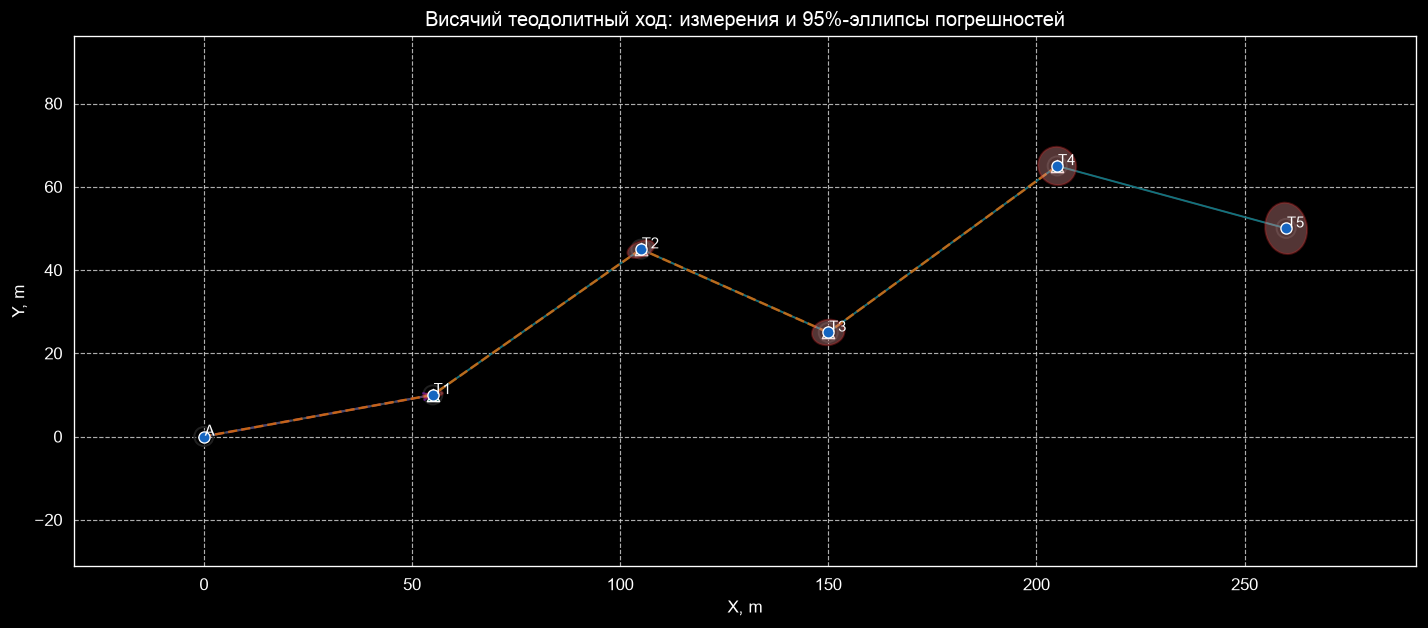

In [24]:
traverse_plot_context = NetworkPlotContext(
    network=traverse_network,
    covariance=traverse_covariance,
    observations=traverse_method.observations,
)

traverse_plot = NetworkPlot(
    title=(
        "Висячий теодолитный ход: "
        "измерения и 95%-эллипсы погрешностей"
    ),
    margin_fraction=0.12,
    equal_aspect=True,
    show_grid=True,
)

traverse_plot.extend_layers(
    (
        ObservationLayer(
            renderers=default_observation_renderers(),
            report_unsupported=True,
        ),
        ErrorEllipseLayer(
            confidence_level=0.95,
            display_scale=500.0,
        ),
        PointLayer(
            show_labels=True,
        ),
    )
)

figure, axes = traverse_plot.draw(
    traverse_plot_context,
    figsize=(12.0, 7.0),
)

axes.set_xlabel("X, m")
axes.set_ylabel("Y, m")

figure.tight_layout()
plt.show()

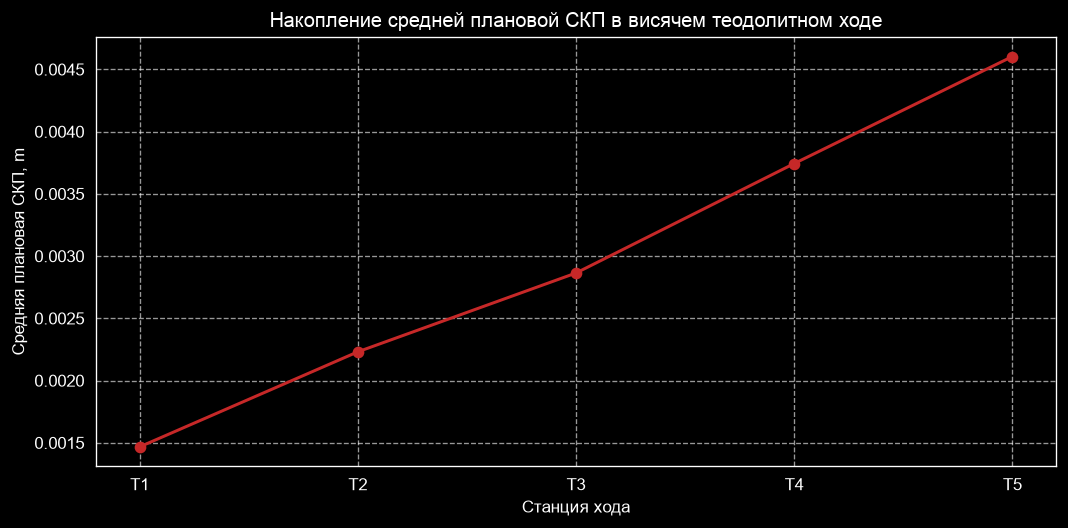

In [25]:
traverse_station_names = (
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
)

plan_standard_deviations = []

for point_name in traverse_station_names:
    point_covariance = traverse_covariance.diagonal_block(
        point_name
    )

    sigma_x = np.sqrt(point_covariance[0, 0])
    sigma_y = np.sqrt(point_covariance[1, 1])

    plan_standard_deviations.append(
        np.sqrt((sigma_x**2 + sigma_y**2) / 2.0)
    )

figure, axes = plt.subplots(
    figsize=(9.0, 4.5),
)

axes.plot(
    traverse_station_names,
    plan_standard_deviations,
    marker="o",
    color="#c62828",
    linewidth=1.8,
)

axes.set_title(
    "Накопление средней плановой СКП "
    "в висячем теодолитном ходе"
)
axes.set_xlabel("Станция хода")
axes.set_ylabel("Средняя плановая СКП, m")
axes.grid(
    visible=True,
    linestyle="--",
    alpha=0.6,
)

figure.tight_layout()
plt.show()

### Интерпретация

Висячий ход имеет только один закреплённый конец. Ошибки расстояний и
углов на каждой станции передаются на все последующие станции.

Поэтому:

- `T1` определяется наиболее точно, поскольку расположена рядом с
  исходным пунктом `A`;
- неопределённость `T2`, `T3`, `T4` накапливается последовательно;
- конечная станция `T5` обычно имеет наибольший эллипс погрешностей;
- удлинённая большая ось эллипса отражает направление, в котором
  геометрия хода слабее всего ограничивает координаты.

В отличие от замкнутого хода или сети с дополнительными связями,
висячий ход не имеет независимого контроля на конечной точке. Добавление
замыкающего измерения от `T5` к исходному или контрольному пункту
существенно улучшит точность и уменьшит эллипс `T5`.

---

## 4. Теодолитный ход, замкнутый на два исходных пункта

Рассмотрим ход между двумя закреплёнными исходными пунктами:

$$
A \rightarrow T_1 \rightarrow T_2 \rightarrow T_3 \rightarrow T_4
\rightarrow T_5 \rightarrow B.
$$

Пункты `A` и `B` имеют фиксированные координаты. Точки `T1`–`T5`
являются определяемыми станциями хода.

На каждой станции измеряются:

- горизонтальные направления назад и вперёд;
- наклонные расстояния между соседними точками.

Замыкание на второй исходный пункт `B` создаёт дополнительную
независимую геометрическую связь. Поэтому точность промежуточных
станций обычно выше, чем у аналогичного висячего хода.

In [26]:
closed_traverse_network = GeodeticNetwork(
    name="Five-station traverse between two fixed points",
    points=(
        make_point("A", 0.0, 0.0, 0.0),

        make_point("T1", 50.0, 15.0, 0.0),
        make_point("T2", 95.0, 50.0, 0.0),
        make_point("T3", 145.0, 30.0, 0.0),
        make_point("T4", 195.0, 70.0, 0.0),
        make_point("T5", 250.0, 55.0, 0.0),

        make_point("B", 310.0, 0.0, 0.0),
    ),
)

In [27]:
closed_direction_sigma = arcseconds_to_radians(2.0)

closed_distance_constant_error = 0.002
closed_distance_ppm_error = 2.0

In [28]:
closed_t1_setup = TotalStationSetup(
    name="T1_closed_setup",
    station="T1",
    reference_target="A",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="A",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
        TotalStationSight(
            target="T2",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
    ),
)

closed_t2_setup = TotalStationSetup(
    name="T2_closed_setup",
    station="T2",
    reference_target="T1",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T1",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
        TotalStationSight(
            target="T3",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
    ),
)

closed_t3_setup = TotalStationSetup(
    name="T3_closed_setup",
    station="T3",
    reference_target="T2",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T2",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
        TotalStationSight(
            target="T4",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
    ),
)

closed_t4_setup = TotalStationSetup(
    name="T4_closed_setup",
    station="T4",
    reference_target="T3",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T3",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
        TotalStationSight(
            target="T5",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
    ),
)

closed_t5_setup = TotalStationSetup(
    name="T5_closed_setup",
    station="T5",
    reference_target="T4",
    east_axis="X",
    north_axis="Y",
    sights=(
        TotalStationSight(
            target="T4",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
        TotalStationSight(
            target="B",
            horizontal_standard_deviation=closed_direction_sigma,
        ),
    ),
)

In [29]:
closed_traverse_distances = (
    SlopeDistanceObservation(
        name="A_to_T1",
        from_point="A",
        to_point="T1",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
    SlopeDistanceObservation(
        name="T1_to_T2",
        from_point="T1",
        to_point="T2",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
    SlopeDistanceObservation(
        name="T2_to_T3",
        from_point="T2",
        to_point="T3",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
    SlopeDistanceObservation(
        name="T3_to_T4",
        from_point="T3",
        to_point="T4",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
    SlopeDistanceObservation(
        name="T4_to_T5",
        from_point="T4",
        to_point="T5",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
    SlopeDistanceObservation(
        name="T5_to_B",
        from_point="T5",
        to_point="B",
        constant_error=closed_distance_constant_error,
        ppm_error=closed_distance_ppm_error,
    ),
)

In [30]:
closed_traverse_height_constraints = tuple(
    ControlPointObservation.fixed(
        name=f"{point_name}_height_fixed",
        point_name=point_name,
        axes=("H",),
        coordinates=(0.0,),
    )
    for point_name in (
        "T1",
        "T2",
        "T3",
        "T4",
        "T5",
    )
)

closed_traverse_method = ObservationCovarianceMethod(
    observations=(
        ControlPointObservation.fixed(
            name="A_fixed",
            point_name="A",
            axes=("X", "Y", "H"),
            coordinates=(0.0, 0.0, 0.0),
        ),
        ControlPointObservation.fixed(
            name="B_fixed",
            point_name="B",
            axes=("X", "Y", "H"),
            coordinates=(310.0, 0.0, 0.0),
        ),
        *closed_traverse_height_constraints,
        *closed_traverse_distances,
        closed_t1_setup,
        closed_t2_setup,
        closed_t3_setup,
        closed_t4_setup,
        closed_t5_setup,
    ),
)

In [31]:
closed_traverse_covariance = (
    closed_traverse_network.compute_covariance(
        closed_traverse_method,
    )
)

closed_traverse_covariance

NetworkCovariance(matrix=array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.19869020e-22,  1.18641003e-21,  0.00000000e+00,
        -2.34424985e-21,  3.16855493e-21,  0.00000000e+00,
        -2.58083739e-21,  2.62988362e-21,  0.00000000e+00,
         1.07432666e-21, -7.22430885e-22,  0.00000000e+00,
         9.70928703e-22,  2.21542294e-21,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        -3.21225491e-22,  2.63600693e-21,  0.00000000e+00,
        -1.32739380e-21,  5.29299960e-21,  0.00000000e+00,
        -1.79354504e-21,  4.62562726e-21,  0.00000000e+00,
        -2.37985354e-22,  6.34078932e-21,  0.00000000e+00,
         2.02353668e-22,  5.25371517e-21,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.0

In [32]:
closed_station_names = (
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
)

print("СКП плановых координат в ходе между A и B:")

for point_name in closed_station_names:
    point_covariance = closed_traverse_covariance.diagonal_block(
        point_name
    )

    sigma_x = np.sqrt(point_covariance[0, 0])
    sigma_y = np.sqrt(point_covariance[1, 1])

    print(
        f"{point_name}: "
        f"σX = {sigma_x:.5f} m, "
        f"σY = {sigma_y:.5f} m"
    )

СКП плановых координат в ходе между A и B:
T1: σX = 0.00176 m, σY = 0.00107 m
T2: σX = 0.00229 m, σY = 0.00174 m
T3: σX = 0.00225 m, σY = 0.00197 m
T4: σX = 0.00245 m, σY = 0.00184 m
T5: σX = 0.00183 m, σY = 0.00150 m


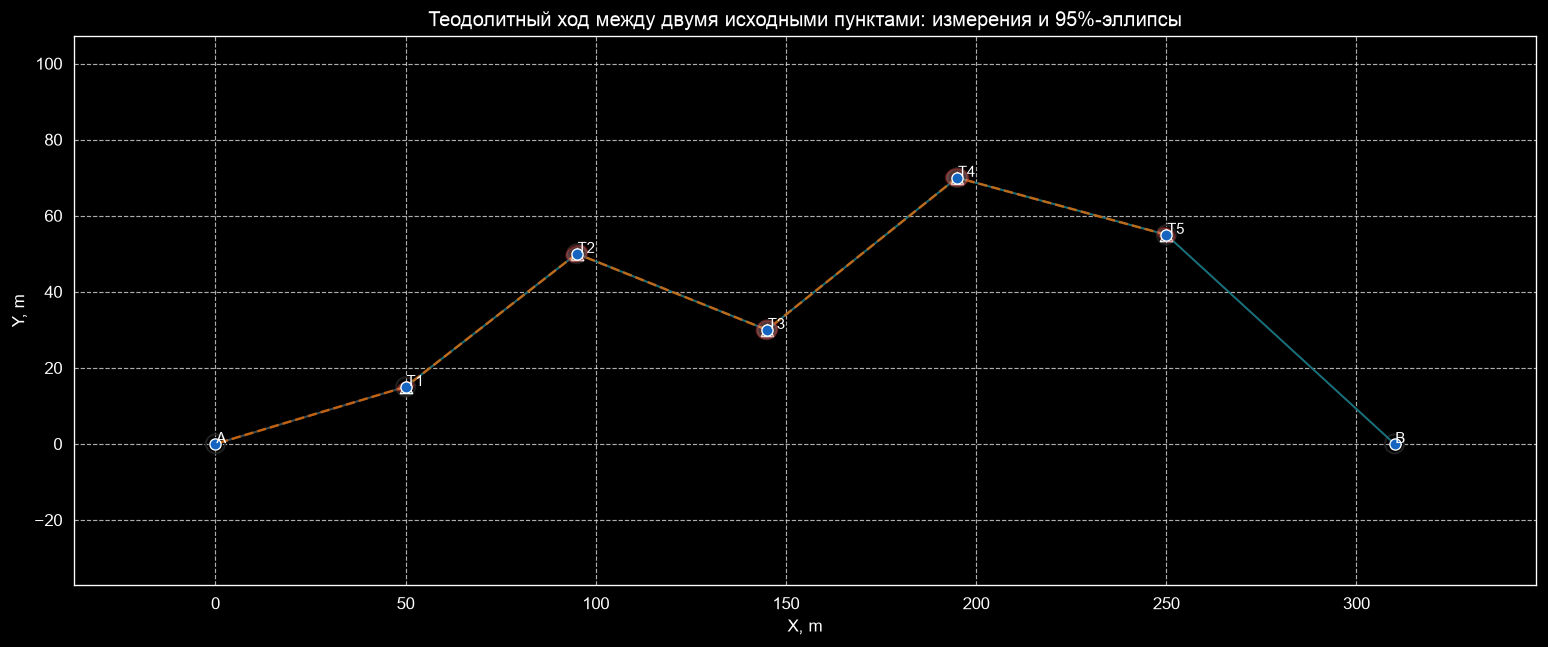

In [33]:
closed_traverse_plot_context = NetworkPlotContext(
    network=closed_traverse_network,
    covariance=closed_traverse_covariance,
    observations=closed_traverse_method.observations,
)

closed_traverse_plot = NetworkPlot(
    title=(
        "Теодолитный ход между двумя исходными пунктами: "
        "измерения и 95%-эллипсы"
    ),
    margin_fraction=0.12,
    equal_aspect=True,
    show_grid=True,
)

closed_traverse_plot.extend_layers(
    (
        ObservationLayer(
            renderers=default_observation_renderers(),
            report_unsupported=True,
        ),
        ErrorEllipseLayer(
            confidence_level=0.95,
            display_scale=500.0,
        ),
        PointLayer(
            show_labels=True,
        ),
    )
)

figure, axes = closed_traverse_plot.draw(
    closed_traverse_plot_context,
    figsize=(13.0, 7.0),
)

axes.set_xlabel("X, m")
axes.set_ylabel("Y, m")

figure.tight_layout()
plt.show()

---

## 5. Ковариационные и корреляционные матрицы ходов

Сравним структуру ковариаций в двух вариантах:

1. Висячий ход, закреплённый только на исходном пункте `A`
2. Ход между двумя фиксированными пунктами `A` и `B`

Ковариационная матрица показывает абсолютные дисперсии и ковариации
координат. Корреляционная матрица нормирует их и позволяет сравнивать
статистические связи параметров независимо от масштаба их СКП.

In [34]:
from covarion.visualization.covariance import (
    plot_correlation_matrix,
    plot_covariance_matrix,
)

In [35]:
def traverse_plan_parameter_indices(
    covariance,
    station_names: tuple[str, ...],
) -> tuple[int, ...]:
    parameter_names = covariance.parameter_names

    indices: list[int] = []

    for station_name in station_names:
        for axis_name in ("X", "Y"):
            parameter_name = f"{station_name}_{axis_name}"

            indices.append(
                parameter_names.index(parameter_name)
            )

    return tuple(indices)


def covariance_submatrix(
    covariance,
    indices: tuple[int, ...],
) -> np.ndarray:
    return covariance.matrix[
        np.ix_(indices, indices)
    ]


def parameter_labels(
    covariance,
    indices: tuple[int, ...],
) -> list[str]:
    return [
        covariance.parameter_names[index]
        for index in indices
    ]

In [36]:
print(closed_traverse_covariance)
print(closed_traverse_covariance.parameter_names)

NetworkCovariance(matrix=array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.19869020e-22,  1.18641003e-21,  0.00000000e+00,
        -2.34424985e-21,  3.16855493e-21,  0.00000000e+00,
        -2.58083739e-21,  2.62988362e-21,  0.00000000e+00,
         1.07432666e-21, -7.22430885e-22,  0.00000000e+00,
         9.70928703e-22,  2.21542294e-21,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        -3.21225491e-22,  2.63600693e-21,  0.00000000e+00,
        -1.32739380e-21,  5.29299960e-21,  0.00000000e+00,
        -1.79354504e-21,  4.62562726e-21,  0.00000000e+00,
        -2.37985354e-22,  6.34078932e-21,  0.00000000e+00,
         2.02353668e-22,  5.25371517e-21,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.0

In [37]:
traverse_station_names = (
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
)

hanging_plan_indices = traverse_plan_parameter_indices(
    traverse_covariance,
    traverse_station_names,
)

closed_plan_indices = traverse_plan_parameter_indices(
    closed_traverse_covariance,
    traverse_station_names,
)

hanging_plan_covariance = covariance_submatrix(
    traverse_covariance,
    hanging_plan_indices,
)

closed_plan_covariance = covariance_submatrix(
    closed_traverse_covariance,
    closed_plan_indices,
)

hanging_plan_labels = parameter_labels(
    traverse_covariance,
    hanging_plan_indices,
)

closed_plan_labels = parameter_labels(
    closed_traverse_covariance,
    closed_plan_indices,
)

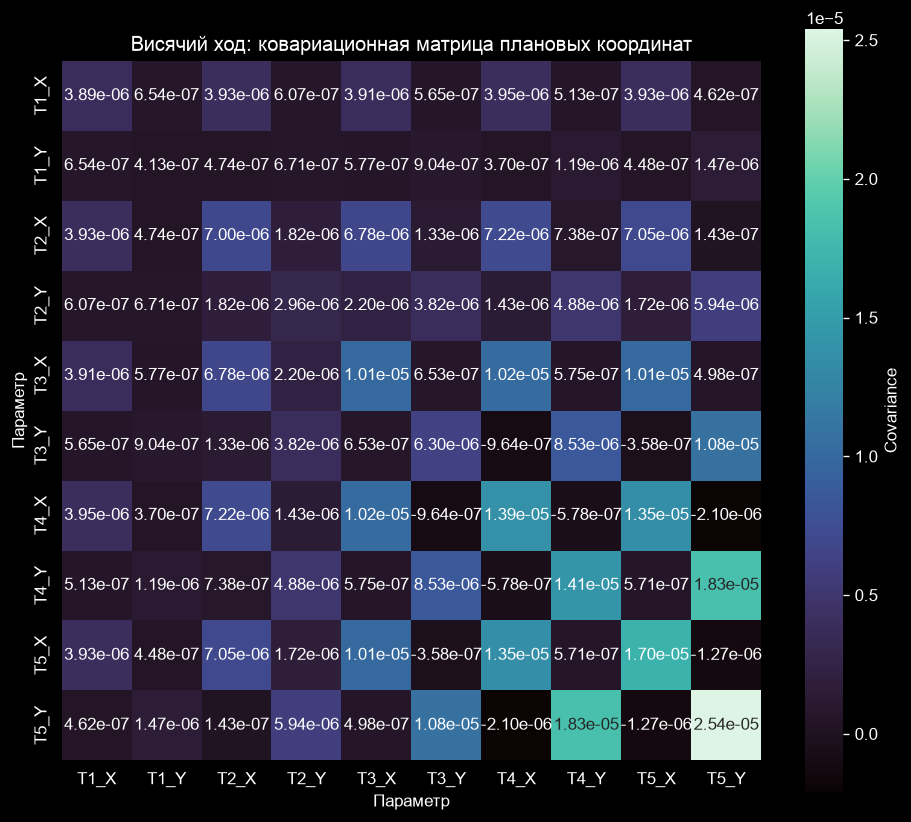

In [38]:
figure, axes = plot_covariance_matrix(
    hanging_plan_covariance,
    hanging_plan_labels,
    annotate=True,
)

axes.set_title(
    "Висячий ход: ковариационная матрица "
    "плановых координат"
)

figure.tight_layout()
plt.show()

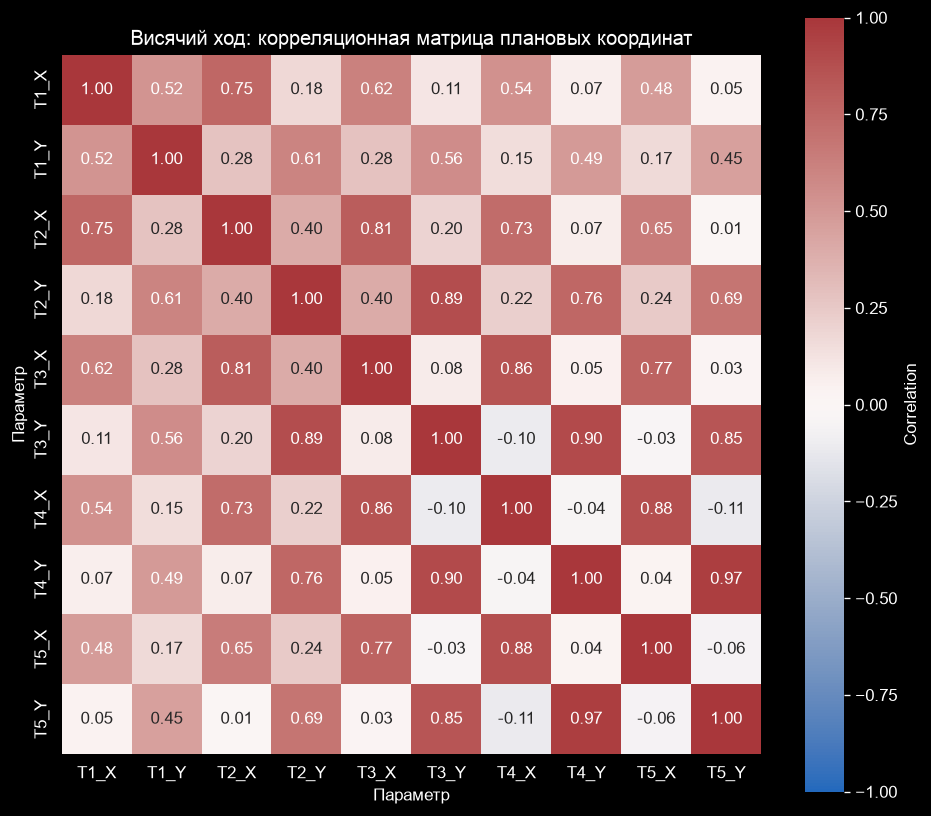

In [39]:
figure, axes = plot_correlation_matrix(
    hanging_plan_covariance,
    hanging_plan_labels,
    annotate=True,
)

axes.set_title(
    "Висячий ход: корреляционная матрица "
    "плановых координат"
)

figure.tight_layout()
plt.show()

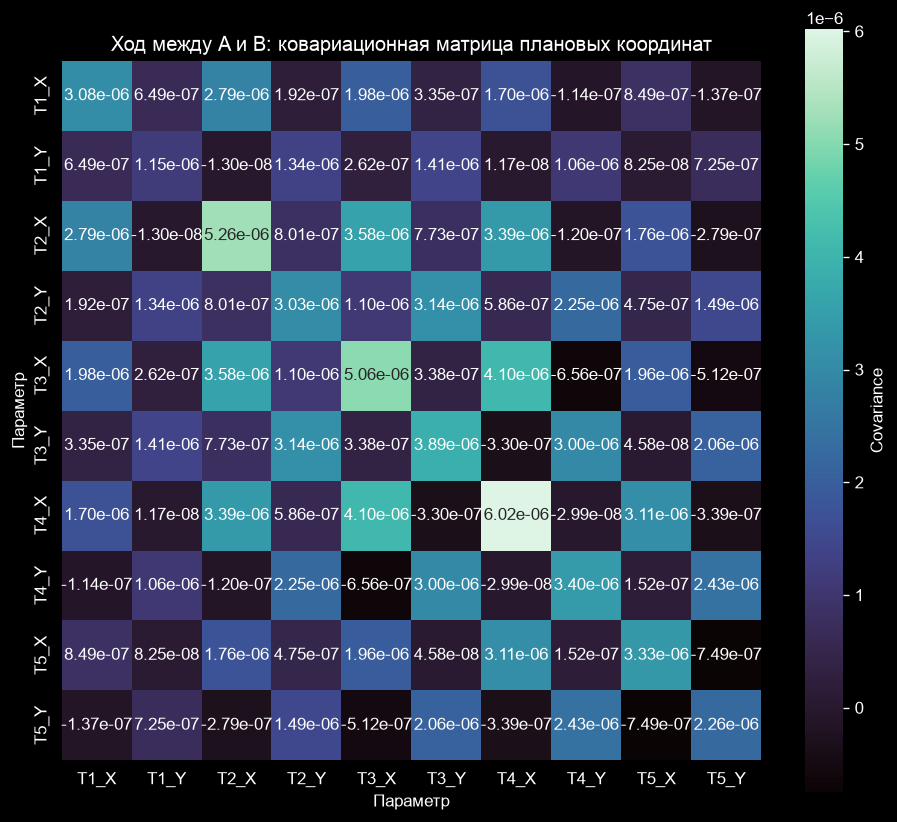

In [40]:
figure, axes = plot_covariance_matrix(
    closed_plan_covariance,
    closed_plan_labels,
    annotate=True,
)

axes.set_title(
    "Ход между A и B: ковариационная матрица "
    "плановых координат"
)

figure.tight_layout()
plt.show()

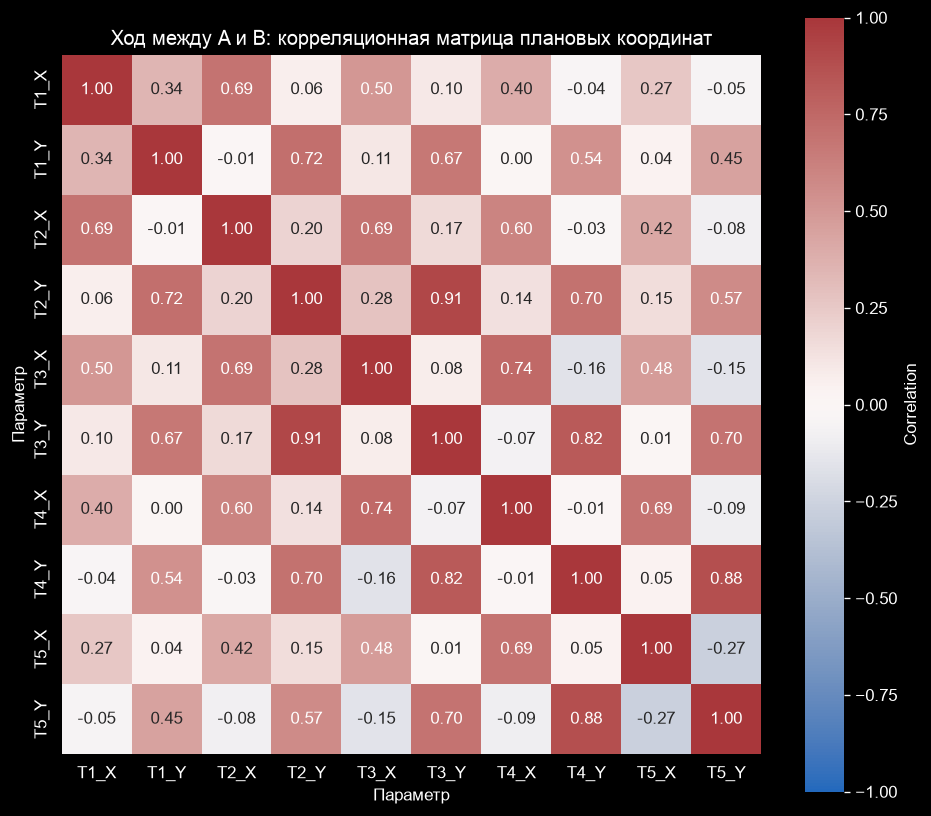

In [41]:
figure, axes = plot_correlation_matrix(
    closed_plan_covariance,
    closed_plan_labels,
    annotate=True,
)

axes.set_title(
    "Ход между A и B: корреляционная матрица "
    "плановых координат"
)

figure.tight_layout()
plt.show()

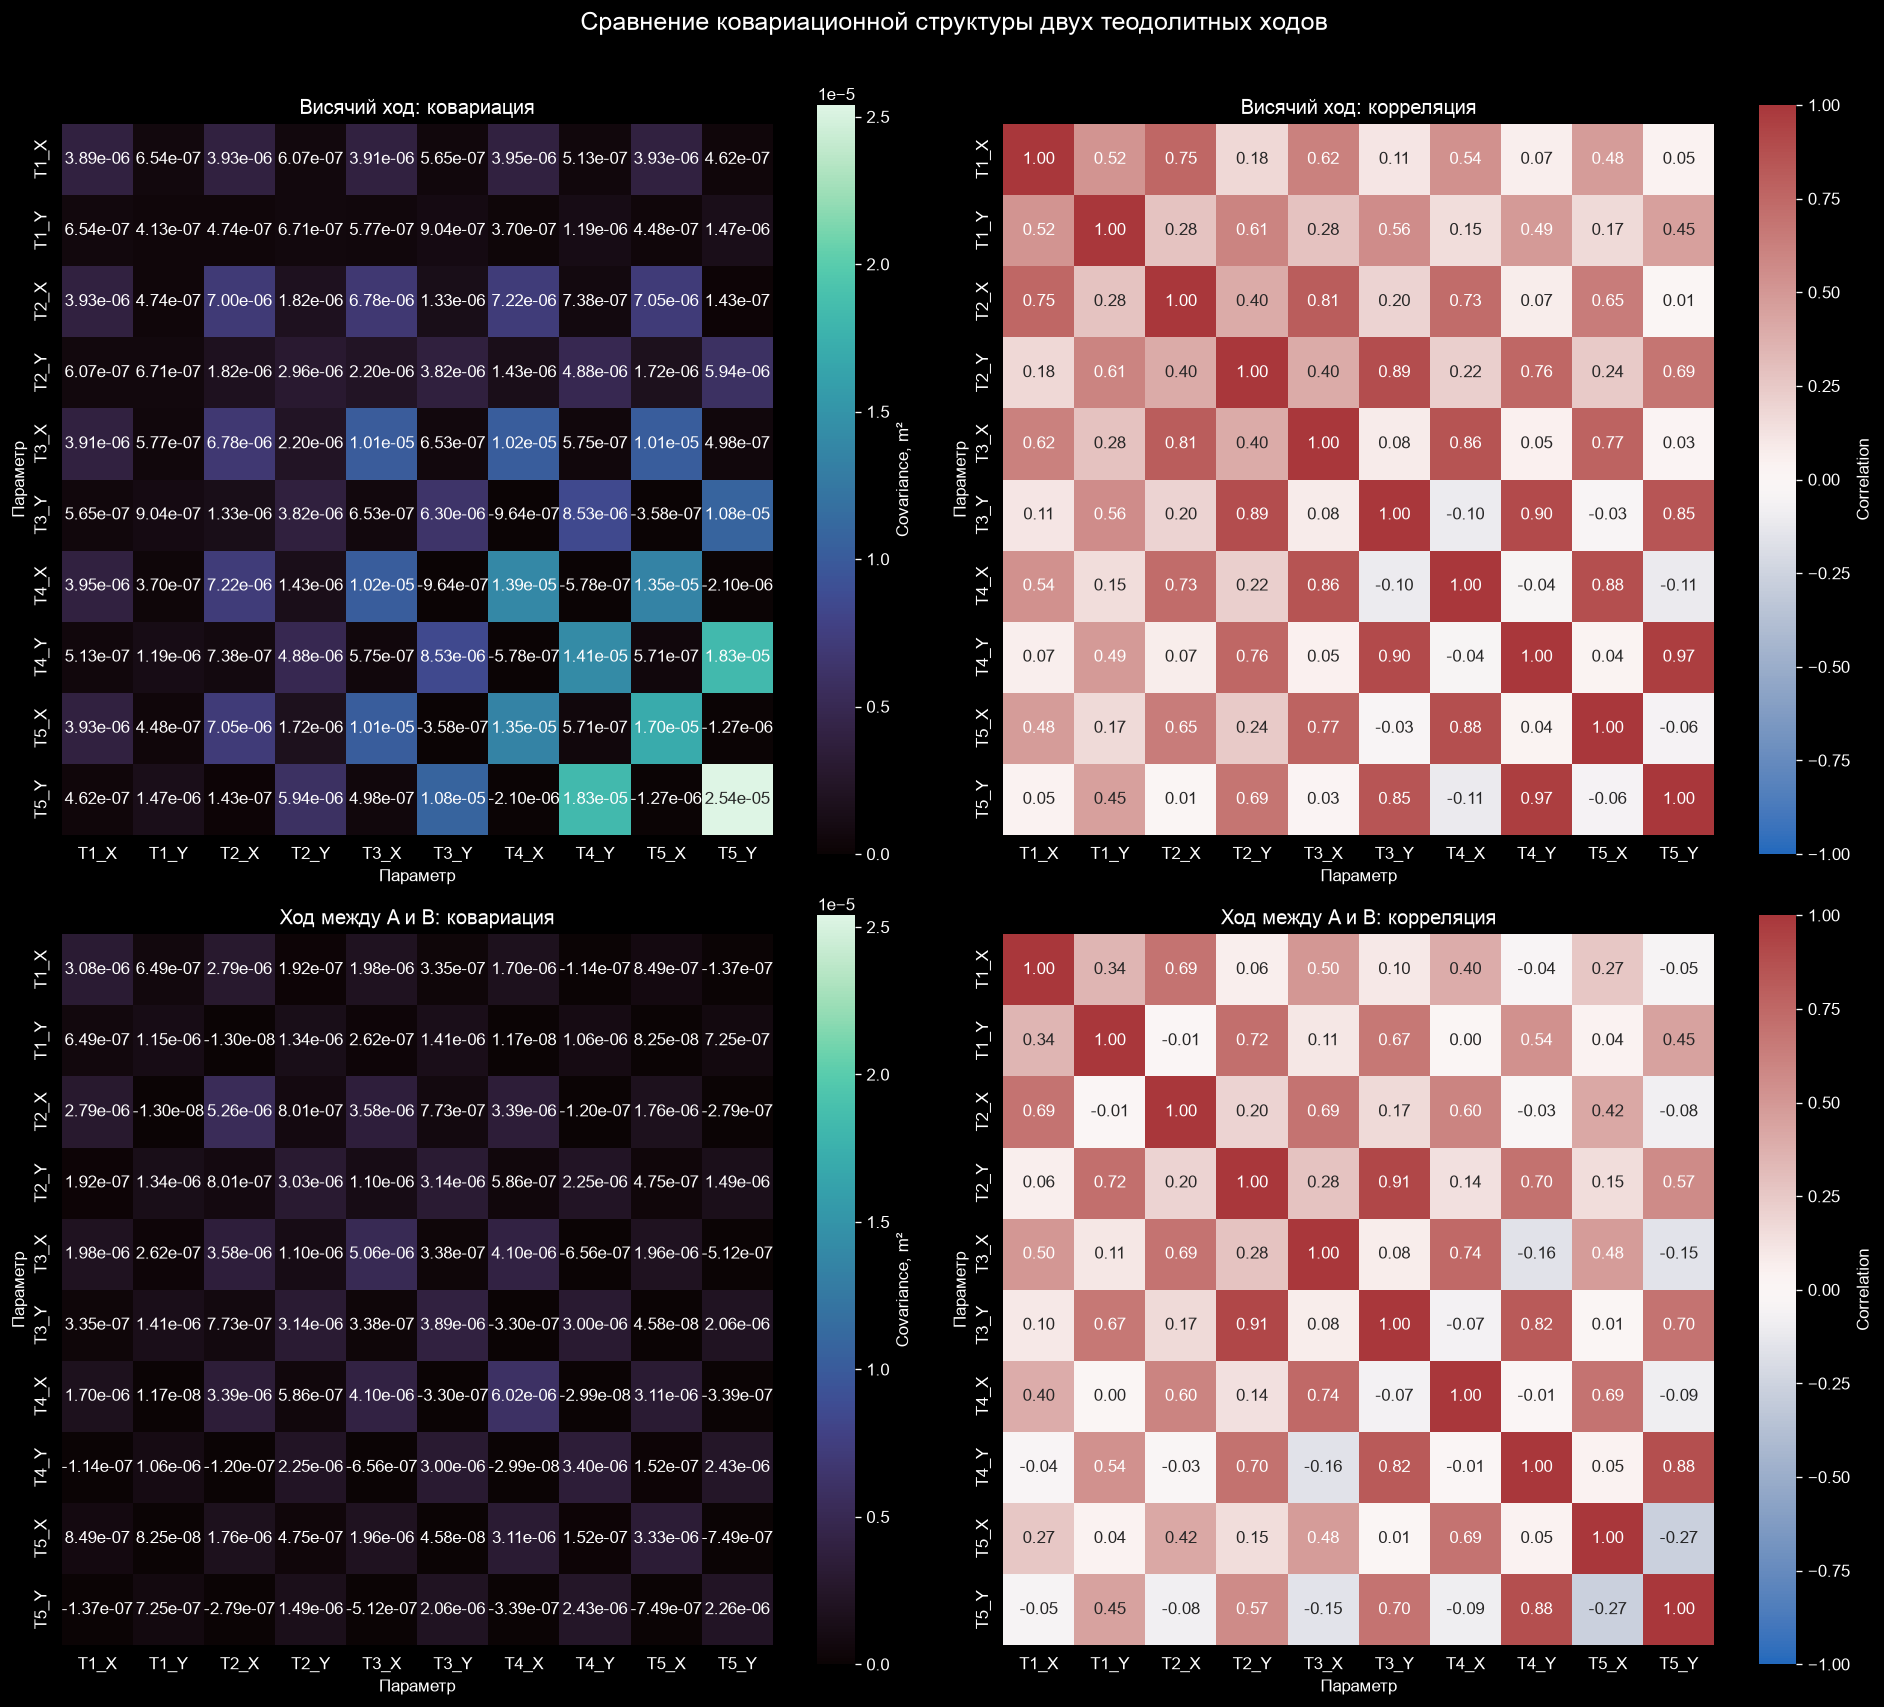

In [42]:
import seaborn as sns


def covariance_to_correlation(
    covariance_matrix: np.ndarray,
) -> np.ndarray:
    standard_deviations = np.sqrt(
        np.diag(covariance_matrix)
    )

    denominator = np.outer(
        standard_deviations,
        standard_deviations,
    )

    return np.divide(
        covariance_matrix,
        denominator,
        out=np.zeros_like(
            covariance_matrix,
            dtype=float,
        ),
        where=denominator > 0.0,
    )


hanging_plan_correlation = covariance_to_correlation(
    hanging_plan_covariance,
)

closed_plan_correlation = covariance_to_correlation(
    closed_plan_covariance,
)

common_covariance_limit = max(
    np.max(np.abs(hanging_plan_covariance)),
    np.max(np.abs(closed_plan_covariance)),
)

figure, axes_grid = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16.0, 14.0),
)

covariance_options = {
    "cmap": "mako",
    "square": True,
    "annot": True,
    "fmt": ".2e",
    "xticklabels": hanging_plan_labels,
    "yticklabels": hanging_plan_labels,
    "vmin": 0.0,
    "vmax": common_covariance_limit,
    "cbar_kws": {
        "label": "Covariance, m²",
    },
}

sns.heatmap(
    hanging_plan_covariance,
    ax=axes_grid[0, 0],
    **covariance_options,
)
axes_grid[0, 0].set_title(
    "Висячий ход: ковариация"
)

sns.heatmap(
    hanging_plan_correlation,
    ax=axes_grid[0, 1],
    cmap="vlag",
    square=True,
    annot=True,
    fmt=".2f",
    xticklabels=hanging_plan_labels,
    yticklabels=hanging_plan_labels,
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    cbar_kws={
        "label": "Correlation",
    },
)
axes_grid[0, 1].set_title(
    "Висячий ход: корреляция"
)

sns.heatmap(
    closed_plan_covariance,
    ax=axes_grid[1, 0],
    cmap="mako",
    square=True,
    annot=True,
    fmt=".2e",
    xticklabels=closed_plan_labels,
    yticklabels=closed_plan_labels,
    vmin=0.0,
    vmax=common_covariance_limit,
    cbar_kws={
        "label": "Covariance, m²",
    },
)
axes_grid[1, 0].set_title(
    "Ход между A и B: ковариация"
)

sns.heatmap(
    closed_plan_correlation,
    ax=axes_grid[1, 1],
    cmap="vlag",
    square=True,
    annot=True,
    fmt=".2f",
    xticklabels=closed_plan_labels,
    yticklabels=closed_plan_labels,
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    cbar_kws={
        "label": "Correlation",
    },
)
axes_grid[1, 1].set_title(
    "Ход между A и B: корреляция"
)

for axes in axes_grid.flat:
    axes.set_xlabel("Параметр")
    axes.set_ylabel("Параметр")

figure.suptitle(
    "Сравнение ковариационной структуры двух теодолитных ходов",
    fontsize=15.0,
    y=1.01,
)

figure.tight_layout()
plt.show()

In [43]:
from covarion.reporting import point_results_dataframe

closed_traverse_results = point_results_dataframe(
    closed_traverse_covariance,
    confidence_level=0.95,
    point_names=(
        "T1",
        "T2",
        "T3",
        "T4",
        "T5",
    ),
)

closed_traverse_results

,point,sigma_x_m,sigma_y_m,sigma_h_m,covariance_xy_m2,correlation_xy,ellipse_major_m,ellipse_minor_m,ellipse_azimuth_deg,confidence_level
0,T1,0.001755,0.001075,0.0,6.492207e-07,0.344201,0.004433,0.002394,73.012062,0.95
1,T2,0.002294,0.001741,0.0,8.009293e-07,0.200479,0.005751,0.004077,72.155112,0.95
2,T3,0.002250,0.001973,0.0,3.384369e-07,0.076227,0.005557,0.004773,74.972084,0.95
3,T4,0.002454,0.001845,0.0,-2.993721e-08,-0.006614,0.006006,0.004516,90.655451,0.95
4,T5,0.001825,0.001504,0.0,-7.493842e-07,-0.272941,0.004719,0.003353,117.259668,0.95


In [44]:
from pathlib import Path

from covarion.reporting import (
    export_point_results_csv,
    export_point_results_txt,
)

report_directory = Path("output")

csv_report_path = export_point_results_csv(
    closed_traverse_results,
    report_directory / "closed_traverse_results.csv",
    separator=";",
    decimal=",",
)

txt_report_path = export_point_results_txt(
    closed_traverse_results,
    report_directory / "closed_traverse_results.txt",
    title=(
        "Теодолитный ход между "
        "исходными пунктами A и B"
    ),
    confidence_level=0.95,
)

print(f"CSV: {csv_report_path}")
print(f"TXT: {txt_report_path}")

CSV: output/closed_traverse_results.csv
TXT: output/closed_traverse_results.txt


In [45]:
from pathlib import Path

from covarion.reporting import export_network_geojson

geojson_path = export_network_geojson(
    network=closed_traverse_network,
    observations=closed_traverse_method.observations,
    covariance=closed_traverse_covariance,
    path=Path("output/closed_traverse.geojson"),
    confidence_level=0.95,
    ellipse_vertices=72,
    coordinate_reference_system="LOCAL_ENGINEERING_XY",
)

print(f"GeoJSON export: {geojson_path}")

GeoJSON export: output/closed_traverse.geojson


In [46]:
hanging_geojson_path = export_network_geojson(
    network=traverse_network,
    observations=traverse_method.observations,
    covariance=traverse_covariance,
    path=Path("output/hanging_traverse.geojson"),
    confidence_level=0.95,
    coordinate_reference_system="LOCAL_ENGINEERING_XY",
)

print(f"GeoJSON export: {hanging_geojson_path}")

GeoJSON export: output/hanging_traverse.geojson


In [47]:
from pathlib import Path

from covarion.reporting import (
    export_network_geojson_layers,
)

closed_traverse_layers = export_network_geojson_layers(
    network=closed_traverse_network,
    observations=closed_traverse_method.observations,
    covariance=closed_traverse_covariance,
    directory=Path("output"),
    name="closed_traverse",
    confidence_level=0.95,
    ellipse_vertices=72,
    ellipse_display_scale=1_000.0,
    coordinate_reference_system="LOCAL_ENGINEERING_XY",
)

for layer_name, path in closed_traverse_layers.items():
    print(f"{layer_name}: {path}")

points: output/closed_traverse_points.geojson
observations: output/closed_traverse_observations.geojson
error_ellipses: output/closed_traverse_error_ellipses.geojson


In [48]:
from pathlib import Path

from covarion.reporting import (
    export_covariance_matrix_csv,
    export_covariance_matrix_txt,
)

output_directory = Path("output")

covariance_csv_path = export_covariance_matrix_csv(
    closed_traverse_covariance,
    output_directory / "closed_traverse_covariance.csv",
    separator=";",
    decimal=",",
)

covariance_txt_path = export_covariance_matrix_txt(
    closed_traverse_covariance,
    output_directory / "closed_traverse_covariance.txt",
    title=(
        "Ковариационная матрица "
        "теодолитного хода между A и B"
    ),
)

print(f"CSV matrix: {covariance_csv_path}")
print(f"TXT matrix: {covariance_txt_path}")

CSV matrix: output/closed_traverse_covariance.csv
TXT matrix: output/closed_traverse_covariance.txt


### Вывод по матрицам

Висячий ход имеет выраженное накопление ошибок: неопределённость ранних
станций передаётся на все последующие. Это проявляется как увеличенные
диагональные элементы и сильные внедиагональные связи в ковариационной
матрице.

Ход, закреплённый на пунктах `A` и `B`, получает ограничения с обеих
сторон. Поэтому его ковариационная матрица обычно имеет меньшие
диагональные элементы, а максимум неопределённости смещается к середине
хода.

Корреляционные матрицы полезны для анализа формы этих зависимостей:
они отделяют наличие статистической связи от абсолютного масштаба
ошибок координат.